# Parallel executions and Extract data

This notework will show you how to run parallel execution of HEC-RAS plans and extract result data of points along the barrier.

- Note: this notebook focuses on parallel execution based on '08_parallel_execution.ipynb' to run 8 plans in parallel, have a look at sequential execution or single plan execution files if you need.

## Parallel execution

In [ ]:
import math
import psutil
from pathlib import Path
from ras_commander import init_ras_project, ras, RasUtils, HdfStruc, HdfResultsPlan, RasPlan, RasCmdr, RasPrj
import pandas as pd
import time
#from IPython import display

In [2]:
# Check system resources for parallel execution
cpu_count = psutil.cpu_count(logical=True)  # Logical cores (including hyper-threading)
physical_cores = psutil.cpu_count(logical=False)  # Physical cores only
memory_gb = psutil.virtual_memory().total / (1024**3)  # Total RAM in GB
available_memory_gb = psutil.virtual_memory().available / (1024**3)  # Available RAM in GB

print(f"System Resources:")
print(f"- {physical_cores} physical CPU cores ({cpu_count} logical cores with hyper-threading)")
print(f"- {memory_gb:.1f} GB total memory ({available_memory_gb:.1f} GB available)")

# Functions to help with resource management
def get_optimal_worker_count(cores_per_worker=2):
    """Calculate the optimal number of workers based on available physical cores."""
    optimal_workers = math.floor(physical_cores / cores_per_worker)
    return max(1, optimal_workers)  # Ensure at least 1 worker

print(f"\nFor parallel HEC-RAS execution:")
print(f"- With 2 cores per worker: Can use up to {get_optimal_worker_count(2)} parallel workers. This means you can run {get_optimal_worker_count(2)} plans in parallel")
print(f"- With 4 cores per worker: Can use up to {get_optimal_worker_count(4)} parallel workers. This means you can run {get_optimal_worker_count(4)} plans in parallel")

System Resources:
- 4 physical CPU cores (8 logical cores with hyper-threading)
- 7.8 GB total memory (0.7 GB available)

For parallel HEC-RAS execution:
- With 2 cores per worker: Can use up to 2 parallel workers. This means you can run 2 plans in parallel
- With 4 cores per worker: Can use up to 1 parallel workers. This means you can run 1 plans in parallel


In [12]:
# Replace with your path to your HEC-RAS project folder
project_path = Path(r"C:\Users\Phuong\OneDrive\Documents\unimelb\Lava intern\barrier_tutorial")
ras_exe = Path(r"C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe") # replace with your path to Ras.exe

# Initialize the project
source_project = init_ras_project(project_path, ras_version=ras_exe)

2025-10-13 01:46:57 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\Users\Phuong\OneDrive\Documents\unimelb\Lava intern\barrier_tutorial\barrier_tutorial.rasmap


We need to create a separate compute folder where it will copy all of your project files and compute results there.

In [13]:
# specific_compute_folder = Path(r"C:\HECRAS\barrier_tutorial\compute")  #  USE THIS IF YOU GET ACCESS DENIED ERROR WHEN EXECUTE SIMULATIONS
specific_compute_folder = project_path / "compute"
print(specific_compute_folder)

# Create specific compute folder if it doesn't exist
specific_compute_folder.mkdir(parents=True, exist_ok=True)

C:\HECRAS\barrier_tutorial\compute


### Important:
ACCESS DENIED ERROR: If you run the cell below and it has 'ACCESS DENIED ERROR' to access the compute folder you've just created, change the specific compute folder up there. I use OneDrive and it raises that error when I create the folder in OneDrive. By changing the path to "C:\HECRAS...", it would solve the Access denied error

* If you change to "C:\HECRAS\barrier_tutorial\compute", you should delete the "compute" folder that you've created in the current project path:
   - The way function compute_parallel() works is that it will first copy all files in current project path to the new compute folder
   - Then create separate folders for each worker, for example worker 1 will compute plan 1, 3, 5, 7; worker 2 will compute the plan 2, 4, 6, 8.
   - Then it will merge all the plans' results back to the 'compute' folder and delete the worker's folder. If you have a "compute" folder in the current project path initially, it will copy that as well to the worker's folder and you will likely get ACCESS DENIED ERROR to delete the worker's folder.
   - This also means you should delete or move any unnecessary folders in the current project path before parallel execution to avoid ACCESS DENIED ERROR to delete those folders. If you have a 'Backup' folder the HEC-RAS created, just moved it somewhere else.

In [14]:
print("Executing specific plans in parallel...")
print("This may take several minutes...")

# Define the plans to execute
specific_plans = ["01", "02", "03", "04", "05", "06", "07", "08"]
print(f"Selected plans: {', '.join(specific_plans)}")

# Define the parameters for parallel execution
max_workers = 2  # One for each plan
cores_per_worker = 2

print(f"Using {max_workers} parallel workers, each with {cores_per_worker} cores")
print(f"Destination folder: {specific_compute_folder}")

# Record start time for performance measurement
start_time = time.time()

# Execute specific plans in parallel
results_specific = RasCmdr.compute_parallel(
    plan_number=specific_plans,
    max_workers=max_workers,
    num_cores=cores_per_worker,
    dest_folder=specific_compute_folder,
    overwrite_dest=True,
    ras_object=source_project
)

# Record end time and calculate duration
end_time = time.time()
specific_duration = end_time - start_time

print(f"Parallel execution of specific plans completed in {specific_duration:.2f} seconds")

# Create a DataFrame from the execution results for better visualization
specific_results_df = pd.DataFrame([
    {"Plan": plan, "Success": success}
    for plan, success in results_specific.items()
])

# Sort by plan number
specific_results_df = specific_results_df.sort_values("Plan")

# Display the results
print("\nExecution Results:")
specific_results_df

2025-10-13 01:47:06 - ras_commander.RasCmdr - INFO - Destination folder 'C:\HECRAS\barrier_tutorial\compute' exists. Overwriting as per overwrite_dest=True.
2025-10-13 01:47:06 - ras_commander.RasCmdr - INFO - Copied project folder to destination: C:\HECRAS\barrier_tutorial\compute
2025-10-13 01:47:06 - ras_commander.RasCmdr - INFO - Filtered plans to execute: ['01', '02', '03', '04', '05', '06', '07', '08']
2025-10-13 01:47:06 - ras_commander.RasCmdr - INFO - Adjusted max_workers to 2 based on the number of plans: 8


Executing specific plans in parallel...
This may take several minutes...
Selected plans: 01, 02, 03, 04, 05, 06, 07, 08
Using 2 parallel workers, each with 2 cores
Destination folder: C:\HECRAS\barrier_tutorial\compute


2025-10-13 01:47:06 - ras_commander.RasCmdr - INFO - Created worker folder: C:\HECRAS\barrier_tutorial\compute [Worker 1]
2025-10-13 01:47:06 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\HECRAS\barrier_tutorial\compute [Worker 1]\barrier_tutorial.rasmap
2025-10-13 01:47:06 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\HECRAS\barrier_tutorial\compute [Worker 1]\barrier_tutorial.rasmap
2025-10-13 01:47:06 - ras_commander.RasCmdr - INFO - Created worker folder: C:\HECRAS\barrier_tutorial\compute [Worker 2]
2025-10-13 01:47:06 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\HECRAS\barrier_tutorial\compute [Worker 2]\barrier_tutorial.rasmap
2025-10-13 01:47:06 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\HECRAS\barrier_tutorial\compute [Worker 2]\barrier_tutorial.rasmap
2025-10-13 01:47:06 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: C:\HECRAS\barrier_tutorial\comput

Parallel execution of specific plans completed in 125.89 seconds

Execution Results:


,Plan,Success
0,01,True
1,02,True
2,03,True
3,04,True
4,05,True
5,06,True
6,07,True
7,08,True


- Running the above cell successfully should create 8 p.0#.hdf files in the 'compute' folder for 8 plans. 
- Check the 'compute' folder and worker's folder: If all plans run successfully but their results are still stored in separate worker's folders, you're likely have an ACCESS DENIED ERROR to merge the results back to 'compute' folder. Check the error message to see which folder raises that error and delete unnecessary folders from the initial project path as mentioned above.

In [75]:
# Check the results in 'compute' folder 

# Initialize the project in 'compute' folder
specific_compute_project = RasPrj()
ras_exe = Path(r"C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe") # replace with your path to Ras.exe
init_ras_project(specific_compute_folder, ras_version=ras_exe, ras_object=specific_compute_project)
print(f"\nInitialized specific compute project: {specific_compute_project.project_name}")

# Check which plans have results
specific_plans_with_results = specific_compute_project.plan_df[specific_compute_project.plan_df['HDF_Results_Path'].notna()]
print(f"Found {len(specific_plans_with_results)} plans with results:")
specific_plans_with_results[['plan_number', 'HDF_Results_Path']]

2025-10-19 02:50:02 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.rasmap
2025-10-19 02:50:02 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.rasmap



Initialized specific compute project: barrier_tutorial
Found 8 plans with results:


,plan_number,HDF_Results_Path
0,01,C:\HECRAS\barrier_tutorial\compute\barrier_tut...
1,02,C:\HECRAS\barrier_tutorial\compute\barrier_tut...
2,03,C:\HECRAS\barrier_tutorial\compute\barrier_tut...
3,04,C:\HECRAS\barrier_tutorial\compute\barrier_tut...
4,05,C:\HECRAS\barrier_tutorial\compute\barrier_tut...
5,06,C:\HECRAS\barrier_tutorial\compute\barrier_tut...
6,07,C:\HECRAS\barrier_tutorial\compute\barrier_tut...
7,08,C:\HECRAS\barrier_tutorial\compute\barrier_tut...


## Extract result data
The results at a coordinate (X, Y) can be extracted by its nearest cell or face id. Cell is used for result such as depth, water surface elevation; face is used for result such as velocity. See plots and functions below to see what nearest cell or face means.

In [146]:
# Use this setting to disable plot generation within the notebook
generate_plots = True
# Use this setting to disable map generation within the notebook
generate_maps = True

# Import the required libraries for this notebook
import h5py
import numpy as np
import pandas as pd
import requests
from tqdm import tqdm
import scipy
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython import display
import psutil
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import subprocess
import sys
import os
import shutil
from datetime import datetime, timedelta
from pathlib import Path  # Ensure pathlib is imported for file operations
import rasterio
from rasterio.plot import show
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
import logging

In [147]:
from ras_commander import init_ras_project, ras, RasUtils, HdfStruc, HdfResultsPlan, RasPlan, RasCmdr
# Initialise the project from your compute folder
specific_compute_folder = Path(r"C:\HECRAS\barrier_tutorial\compute") # replace with your path to "compute" folder storing the results 
ras_exe = Path(r"C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe") # replace with your path to Ras.exe
init_ras_project(specific_compute_folder, ras_version=ras_exe)

2025-10-19 23:02:13 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.rasmap


### Nearest face id

In [148]:
from ras_commander import HdfMesh
# Get mesh cell faces as geodataframe
plan_number = "08"
geom_hdf_path = ras.plan_df.loc[ras.plan_df['plan_number'] == plan_number, 'Geom Path'].values[0] + '.hdf'
mesh_cell_faces_gdf = HdfMesh.get_mesh_cell_faces(geom_hdf_path)
mesh_cell_faces_gdf

2025-10-19 23:02:17 - ras_commander.HdfMesh - INFO - Using HDF file from direct string path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:18 - ras_commander.HdfMesh - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:18 - ras_commander.HdfMesh - INFO - Using existing Path object HDF file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:18 - ras_commander.HdfMesh - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:18 - ras_commander.HdfBase - INFO - Using HDF file from h5py.File object: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:18 - ras_commander.HdfBase - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:18 - ras_commander.HdfBase - INFO - Found projection in HDF file: C:\HECRAS\barrier_tutorial\comp

,mesh_name,face_id,geometry
0,Perimeter 1,0,"LINESTRING (342446.087 382682.415, 342508.381 ..."
1,Perimeter 1,1,"LINESTRING (342508.381 382620.12, 342608.381 3..."
2,Perimeter 1,2,"LINESTRING (342608.381 382620.12, 342608.381 3..."
3,Perimeter 1,3,"LINESTRING (342608.381 382720.12, 342550.545 3..."
4,Perimeter 1,4,"LINESTRING (342550.545 382777.956, 342446.087 ..."
...,...,...,...
3220,Perimeter 1,3220,"LINESTRING (341208.381 377468.818, 341308.381 ..."
3221,Perimeter 1,3221,"LINESTRING (341808.381 377464.972, 341908.381 ..."
3222,Perimeter 1,3222,"LINESTRING (342596.645 382820.12, 342550.545 3..."
3223,Perimeter 1,3223,"LINESTRING (340586.422 380981.502, 340578.052 ..."


In [149]:
# Function to find the nearest cell face to a given point
def find_nearest_cell_face(point, cell_faces_df):
    """
    Find the nearest cell face to a given point.

    Args:
        point (shapely.geometry.Point): The input point.
        cell_faces_df (GeoDataFrame): DataFrame containing cell face linestrings.

    Returns:
        int: The face_id of the nearest cell face.
        float: The distance to the nearest cell face.
    """
    # Calculate distances from the input point to all cell faces
    distances = cell_faces_df.geometry.distance(point)

    # Find the index of the minimum distance
    nearest_index = distances.idxmin()

    # Get the face_id and distance of the nearest cell face
    nearest_face_id = cell_faces_df.loc[nearest_index, 'face_id']
    nearest_distance = distances[nearest_index]

    return nearest_face_id, nearest_distance

# Example usage
print("\nFinding the nearest cell face to a given point")

# Create a sample point (you can replace this with any point of interest)
from shapely.geometry import Point
from geopandas import GeoDataFrame

# Get the centroid of the mesh cell faces
print("Getting Centroid of 2D Mesh Polygon")
centroid = mesh_cell_faces_gdf.geometry.union_all().centroid

# Create GeoDataFrame with the centroid point, using same CRS as mesh_cell_faces_gdf
sample_point = GeoDataFrame(
    {'geometry': [centroid]}, 
    crs=mesh_cell_faces_gdf.crs
)

if not mesh_cell_faces_gdf.empty and not sample_point.empty:
    print("Searching Cell")
    nearest_face_id, distance = find_nearest_cell_face(sample_point.geometry.iloc[0], mesh_cell_faces_gdf)
    print(f"Nearest cell face to point {sample_point.geometry.iloc[0].coords[0]}:")
    print(f"Face ID: {nearest_face_id}")
    print(f"Distance: {distance:.2f} units")


Finding the nearest cell face to a given point
Getting Centroid of 2D Mesh Polygon
Searching Cell
Nearest cell face to point (342305.978379891, 380114.0980049186):
Face ID: 1735
Distance: 2.40 units


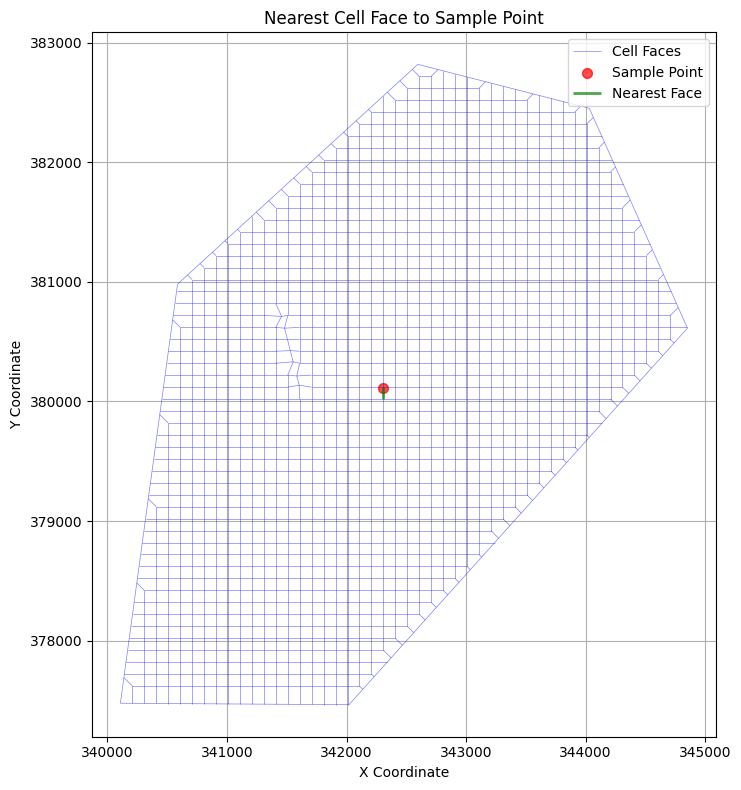

In [82]:
# Generate map of cell faces with sample point and nearest cell face shown
if generate_maps:
    # Visualize the result
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot all cell faces
    mesh_cell_faces_gdf.plot(ax=ax, color='blue', linewidth=0.5, alpha=0.5, label='Cell Faces')
    
    # Plot the sample point
    sample_point.plot(ax=ax, color='red', markersize=50, alpha=0.7, label='Sample Point')
    
    # Plot the nearest cell face
    nearest_face = mesh_cell_faces_gdf[mesh_cell_faces_gdf['face_id'] == nearest_face_id]
    nearest_face.plot(ax=ax, color='green', linewidth=2, alpha=0.7, label='Nearest Face')
    
    # Set labels and title
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title('Nearest Cell Face to Sample Point')
    
    # Add legend and grid
    ax.legend()
    ax.grid(True)
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()
else:
    print("generate_maps is set to False")

### Nearest cell id

In [150]:
from ras_commander import HdfBase
# Extracting projection, we need this to find nearest cell id
print("\nExtracting Projection from HDF")
projection = HdfBase.get_projection(hdf_path=geom_hdf_path)
projection

2025-10-19 23:02:28 - ras_commander.HdfBase - INFO - Using HDF file from direct string path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:28 - ras_commander.HdfBase - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:02:28 - ras_commander.HdfBase - INFO - Found projection in HDF file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf



Extracting Projection from HDF


'PROJCS["Lambert_Conformal_Conic",GEOGCS["GCS_ISN_1993",DATUM["D_Islands_Network_1993",SPHEROID["GRS_1980",6378137.0,298.257222101004]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",500000.0],PARAMETER["Central_Meridian",-19.0],PARAMETER["Standard_Parallel_1",64.25],PARAMETER["Standard_Parallel_2",65.75],PARAMETER["Latitude_Of_Origin",65.0],UNIT["Meter",1.0]]'

In [152]:
# Extract Cell Info
print("\nExample 5: Extracting Cell Info")
cell_info_df = HdfMesh.get_mesh_cell_points(geom_hdf_path)
cell_info_df

2025-10-19 23:04:41 - ras_commander.HdfMesh - INFO - Using HDF file from direct string path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:04:41 - ras_commander.HdfMesh - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:04:41 - ras_commander.HdfMesh - INFO - Using existing Path object HDF file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:04:41 - ras_commander.HdfMesh - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf



Example 5: Extracting Cell Info


2025-10-19 23:04:41 - ras_commander.HdfBase - INFO - Using HDF file from h5py.File object: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:04:41 - ras_commander.HdfBase - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:04:41 - ras_commander.HdfBase - INFO - Found projection in HDF file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf


,mesh_name,cell_id,geometry
0,Perimeter 1,0,POINT (342658.381 382770.12)
1,Perimeter 1,1,POINT (342558.381 382670.12)
2,Perimeter 1,2,POINT (342658.381 382670.12)
3,Perimeter 1,3,POINT (342758.381 382670.12)
4,Perimeter 1,4,POINT (342858.381 382670.12)
...,...,...,...
1695,Perimeter 1,1695,POINT (341258.381 377468.497)
1696,Perimeter 1,1696,POINT (341858.381 377464.651)
1697,Perimeter 1,1697,POINT (342573.595 382799.038)
1698,Perimeter 1,1698,POINT (340582.237 380950.811)



Finding the nearest cell to a given point
Using projection: PROJCS["Lambert_Conformal_Conic",GEOGCS["GCS_ISN_1993",DATUM["D_Islands_Network_1993",SPHEROID["GRS_1980",6378137.0,298.257222101004]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",500000.0],PARAMETER["Central_Meridian",-19.0],PARAMETER["Standard_Parallel_1",64.25],PARAMETER["Standard_Parallel_2",65.75],PARAMETER["Latitude_Of_Origin",65.0],UNIT["Meter",1.0]]
Nearest cell to point (342305.978379891, 380114.0980049186):
Cell ID: 829
Distance: 64.80 units


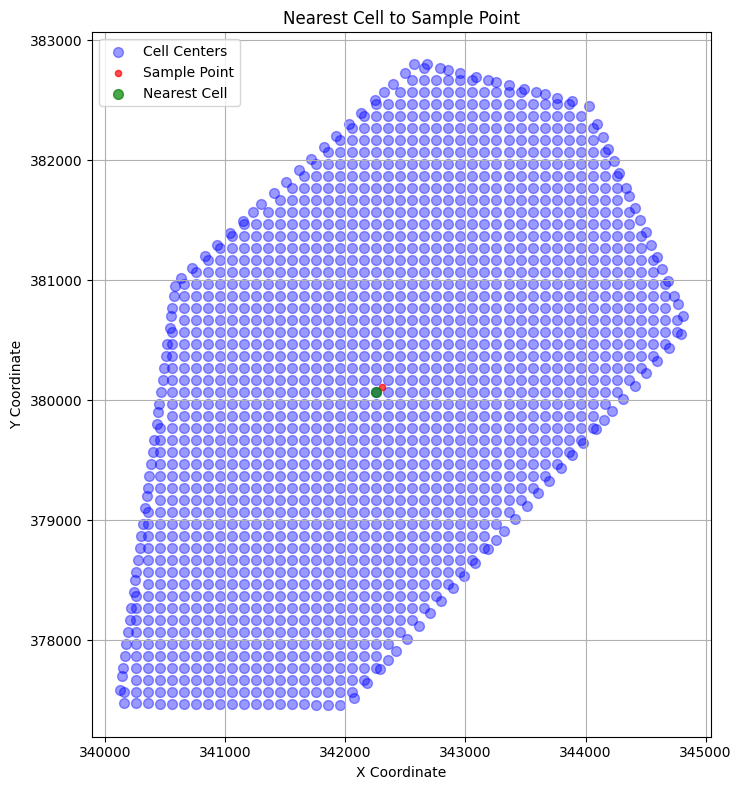

In [89]:
# Function to find the nearest cell center to a given point
def find_nearest_cell(point, cell_centers_df):
    """
    Find the nearest cell center to a given point.

    Args:
        point (shapely.geometry.Point): The input point.
        cell_centers_df (GeoDataFrame): DataFrame containing cell center points.

    Returns:
        int: The cell_id of the nearest cell.
        float: The distance to the nearest cell center.
    """
    # Calculate distances from the input point to all cell centers
    distances = cell_centers_df.geometry.distance(point)

    # Find the index of the minimum distance
    nearest_index = distances.idxmin()

    # Get the cell_id and distance of the nearest cell
    nearest_cell_id = cell_centers_df.loc[nearest_index, 'cell_id']
    nearest_distance = distances[nearest_index]

    return nearest_cell_id, nearest_distance

# Example usage
print("\nFinding the nearest cell to a given point")

# Sample point was created in a previous code cell 

# Get the projection from the geometry file
# projection = HdfUtils.get_projection(hdf_path=geom_hdf_path) # This was done in a previous code cell
if projection:
    print(f"Using projection: {projection}")
else:
    print("No projection information found. Using default CRS.")
    projection = "EPSG:4326"  # Default to WGS84 if no projection is found



# Ensure the CRS of the sample point matches the cell_info_df
if sample_point.crs != cell_info_df.crs:
    sample_point = sample_point.to_crs(cell_info_df.crs)

nearest_cell_id, distance = find_nearest_cell(sample_point.geometry.iloc[0], cell_info_df)
print(f"Nearest cell to point {sample_point.geometry.iloc[0].coords[0]}:")
print(f"Cell ID: {nearest_cell_id}")
print(f"Distance: {distance:.2f} units")

if generate_maps:
    # Visualize the result
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot all cell centers
    cell_info_df.plot(ax=ax, color='blue', markersize=50, alpha=0.4, label='Cell Centers')

    # Plot the sample point
    sample_point.plot(ax=ax, color='red', markersize=20, alpha=0.7, label='Sample Point')

    # Plot the nearest cell center
    nearest_cell = cell_info_df[cell_info_df['cell_id'] == nearest_cell_id]
    nearest_cell.plot(ax=ax, color='green', markersize=50, alpha=0.7, label='Nearest Cell')

    # Set labels and title
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title('Nearest Cell to Sample Point')

    # Add legend and grid
    ax.legend()
    ax.grid(True)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()
else:
    print("generate_maps is set to False")

### Sample points along the barrier

2025-10-19 14:23:31 - ras_commander.HdfStruc - INFO - Using HDF file from direct string path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 14:23:31 - ras_commander.HdfStruc - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 14:23:31 - ras_commander.HdfBase - INFO - Using existing Path object HDF file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 14:23:31 - ras_commander.HdfBase - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 14:23:31 - ras_commander.HdfBase - INFO - Found projection in HDF file: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 14:23:32 - ras_commander.HdfStruc - INFO - Successfully extracted structures GeoDataFrame.
2025-10-19 14:23:32 - ras_commander.HdfStruc - INFO - Successfully extracted structures GeoDataFrame with attributes.


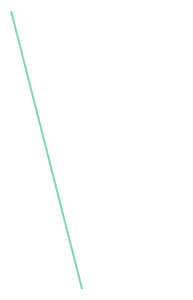

In [139]:
from pathlib import Path
import numpy as np
import pandas as pd
from shapely.geometry import LineString, Point
from shapely.ops import substring
from ras_commander import HdfStruc

structures = HdfStruc.get_structures(geom_hdf_path) # this structure contains info about barrier

row = structures.iloc[0]
barrier: LineString = row["geometry"]
if line is None or line.is_empty:
    raise ValueError("Selected structure has no valid geometry.")
barrier

This is what our barrier looks like, we will sample points along this barrier.

In [163]:
# Define number of points to sample
n_samples_per_100m = 1 # change this as you need
length = line.length  # in map units (meters if your CRS is metric)
n_samples = max(2, int(n_samples_per_100m * (length / 100.0)))
print(f"Length of barrier: {length}")
print(f"Number of points to sample: {n_samples}")

# Parameterize along line in [0,1]
params = np.linspace(0.0, 1.0, n_samples)
print(f"Distribution of points along the line: {params}")

Length of barrier: 594.5814227988076
Number of points to sample: 5
Distribution of points along the line: [0.   0.25 0.5  0.75 1.  ]


In [164]:
# Get sample coordinates
def point_at(p):
    return line.interpolate(p, normalized=True)
xy = np.array([[point_at(p).x, point_at(p).y] for p in params]) # numpy array

# Convert to Points
sample_points = [Point(coords) for coords in xy]

# Wrap in GeoDataFrame with same CRS as your mesh
sample_points_gdf = GeoDataFrame({'geometry': sample_points}, crs=mesh_cell_faces_gdf.crs)
sample_points_gdf

,geometry
0,POINT (341456.702 380711.838)
1,POINT (341493.474 380567.813)
2,POINT (341530.246 380423.788)
3,POINT (341567.019 380279.762)
4,POINT (341603.791 380135.737)


In [165]:
# Get nearest face id of sample points
sample_points_fid = []

# Iterate over each point
for i in range(len(sample_points_gdf)):
    nearest_face_id, distance = find_nearest_cell_face(sample_points_gdf.geometry.iloc[i], mesh_cell_faces_gdf)
    sample_points_fid.append(nearest_face_id)

# Display the results
for i, fid in enumerate(sample_points_fid):
    print(f"Point {i}: Nearest face_id = {fid}")

Point 0: Nearest face_id = 1125
Point 1: Nearest face_id = 1298
Point 2: Nearest face_id = 1479
Point 3: Nearest face_id = 1559
Point 4: Nearest face_id = 1644


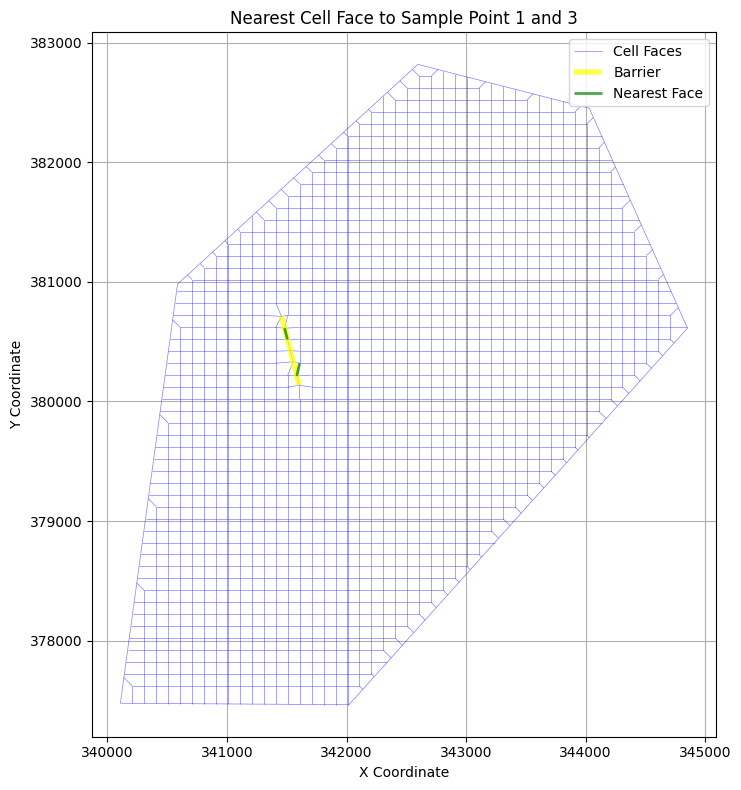

In [157]:
# Example plot of some sample points
barrier_gdf = GeoDataFrame(
    {'geometry': [barrier]},
    crs=mesh_cell_faces_gdf.crs  # use same CRS
)

if generate_maps:
    # Visualize the result
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot all cell faces
    mesh_cell_faces_gdf.plot(ax=ax, color='blue', linewidth=0.5, alpha=0.5, label='Cell Faces')
    barrier_gdf.plot(ax=ax, color='yellow', linewidth=4, alpha=0.7, label='Barrier')
    
    # Plot the nearest face to point 1 and 3
    nearest_face1 = mesh_cell_faces_gdf[mesh_cell_faces_gdf['face_id'] == sample_points_fid[1]]
    nearest_face1.plot(ax=ax, color='green', linewidth=2, alpha=0.7, label='Nearest Face')

    nearest_face3 = mesh_cell_faces_gdf[mesh_cell_faces_gdf['face_id'] == sample_points_fid[3]]
    nearest_face3.plot(ax=ax, color='green', linewidth=2, alpha=0.7)
    
    # Set labels and title
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title('Nearest Cell Face to Sample Point 1 and 3')
    
    # Add legend and grid
    ax.legend()
    ax.grid(True)
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()
else:
    print("generate_maps is set to False")

We can see that some nearest faces are exactly on the barrier, some nearest faces are slightly deviated. Let's find nearest cells now!

In [154]:
# Get nearest cell id of sample points
sample_points_cid = []

#projection = HdfBase.get_projection(hdf_path=geom_hdf_path) # This was done in a previous code cell
if projection:
    print(f"Using projection: {projection}")
else:
    print("No projection information found. Using default CRS.")
    projection = "EPSG:4326"  # Default to WGS84 if no projection is found

# Ensure the CRS of the sample points matches the cell_info_df
if sample_points_gdf.crs != cell_info_df.crs:
    sample_points_gdf = sample_points_gdf.to_crs(cell_info_df.crs)
    
# Iterate over each point
for i in range(len(sample_points_gdf)):
    nearest_cell_id, distance = find_nearest_cell(sample_points_gdf.geometry.iloc[i], cell_info_df)
    sample_points_cid.append(nearest_cell_id)

# Display the results
for i, cid in enumerate(sample_points_cid):
    print(f"Point {i}: Nearest cell_id = {cid}")

Using projection: PROJCS["Lambert_Conformal_Conic",GEOGCS["GCS_ISN_1993",DATUM["D_Islands_Network_1993",SPHEROID["GRS_1980",6378137.0,298.257222101004]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",500000.0],PARAMETER["Central_Meridian",-19.0],PARAMETER["Standard_Parallel_1",64.25],PARAMETER["Standard_Parallel_2",65.75],PARAMETER["Latitude_Of_Origin",65.0],UNIT["Meter",1.0]]
Point 0: Nearest cell_id = 573
Point 1: Nearest cell_id = 616
Point 2: Nearest cell_id = 660
Point 3: Nearest cell_id = 743
Point 4: Nearest cell_id = 783


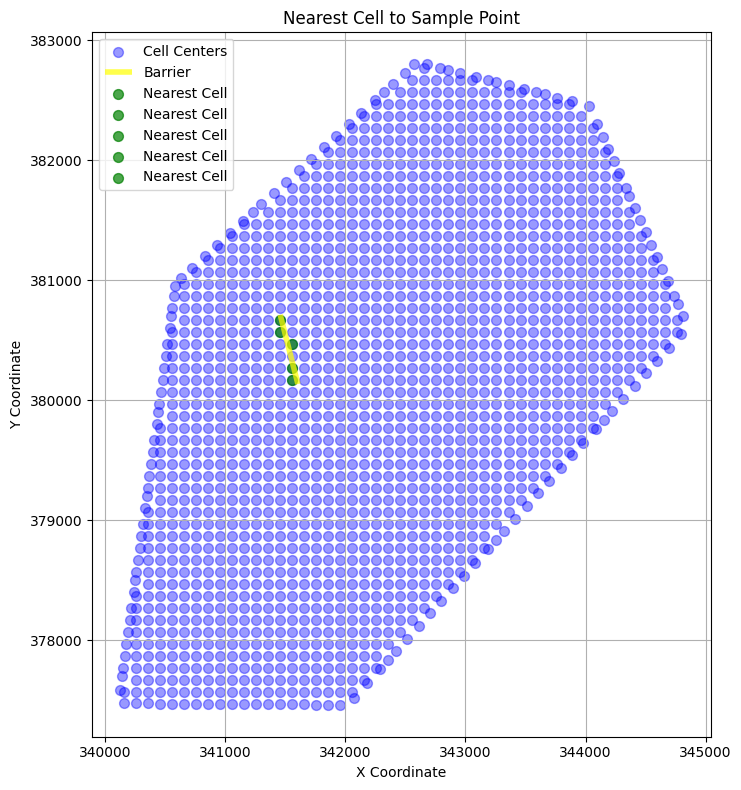

In [162]:
if generate_maps:
    # Visualize the result
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot all cell centers
    cell_info_df.plot(ax=ax, color='blue', markersize=50, alpha=0.4, label='Cell Centers')
    barrier_gdf.plot(ax=ax, color='yellow', linewidth=4, alpha=0.7, label='Barrier')

    # Plot the nearest cell centers
    for i in range(len(sample_points_cid)):
        nearest_cell = cell_info_df[cell_info_df['cell_id'] == sample_points_cid[i]]
        nearest_cell.plot(ax=ax, color='green', markersize=50, alpha=0.7, label='Nearest Cell')

    # Set labels and title
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title('Nearest Cell to Sample Point')

    # Add legend and grid
    ax.legend()
    ax.grid(True)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()
else:
    print("generate_maps is set to False")

* Note for next interns: I think it would be best to get the nearest cells to be 'at the front' of the barrier because that would better allows us to calculate the force acting on the barrier. You can make some improvements to the code to do this!

### Extract results of points along barrier

In [166]:
from ras_commander import HdfPlan, HdfMesh, HdfResultsMesh
mesh_areas = HdfMesh.get_mesh_area_names(geom_hdf_path)
mesh_areas[0]

2025-10-19 23:21:38 - ras_commander.HdfMesh - INFO - Using HDF file from direct string path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf
2025-10-19 23:21:38 - ras_commander.HdfMesh - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.g08.hdf


'Perimeter 1'

In [167]:
# Get the plan HDF path for the plan_number defined above
plan_hdf_path = ras.plan_df.loc[ras.plan_df['plan_number'] == plan_number, 'HDF_Results_Path'].values[0]

# Get timeseries data
cells_timeseries_xr = HdfResultsMesh.get_mesh_cells_timeseries(plan_hdf_path, [mesh_areas[0]])
cells_timeseries_xr

2025-10-19 23:22:23 - ras_commander.HdfResultsMesh - INFO - Using HDF file from direct string path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.p08.hdf
2025-10-19 23:22:23 - ras_commander.HdfResultsMesh - INFO - Final validated HDF file path: C:\HECRAS\barrier_tutorial\compute\barrier_tutorial.p08.hdf
2025-10-19 23:22:23 - ras_commander.HdfResultsMesh - WARNING - Variable 'Depth' not found in the HDF file for mesh 'Perimeter 1'. Skipping.
2025-10-19 23:22:23 - ras_commander.HdfResultsMesh - WARNING - Variable 'Velocity' not found in the HDF file for mesh 'Perimeter 1'. Skipping.
2025-10-19 23:22:23 - ras_commander.HdfResultsMesh - WARNING - Variable 'Velocity X' not found in the HDF file for mesh 'Perimeter 1'. Skipping.
2025-10-19 23:22:23 - ras_commander.HdfResultsMesh - WARNING - Variable 'Velocity Y' not found in the HDF file for mesh 'Perimeter 1'. Skipping.
2025-10-19 23:22:23 - ras_commander.HdfResultsMesh - WARNING - Variable 'Froude Number' not found in the HDF file fo

{'Perimeter 1': <xarray.Dataset> Size: 2MB
 Dimensions:        (time: 97, cell_id: 1700, face_id: 3225)
 Coordinates:
   * time           (time) datetime64[ns] 776B 2008-09-01 ... 2008-09-05
   * cell_id        (cell_id) int64 14kB 0 1 2 3 4 5 ... 1695 1696 1697 1698 1699
   * face_id        (face_id) int64 26kB 0 1 2 3 4 5 ... 3220 3221 3222 3223 3224
 Data variables:
     Water Surface  (time, cell_id) float32 660kB 172.7 163.9 ... 168.3 90.27
     Face Velocity  (time, face_id) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
 Attributes:
     mesh_name:   Perimeter 1
     start_time:  2008-09-01 00:00:00}

- In the 'Data variables' section, the variables appear are the ones that are available. What I'm having are 'Water Surface' and 'Face Velocity', check what you have! 

- Water Surface means original Terrain elevation + Depth; so to get Depth from this we take Water Surface - Terrain. If you already have Depth data, you don't have to subtract.

In [171]:
# Extract Water Surface data
water_surface = cells_timeseries_xr[mesh_areas[0]]['Water Surface']

# Get the time values (optional, only when you want to plot it)
#time_values = water_surface.coords['time'].values

# Extract the water surface elevation time series for cells along the barrier
wsel_timeseries = []
for i in range(len(sample_points_cid)):
    wsel = water_surface.sel(cell_id=sample_points_cid[i])
    wsel_timeseries.append(wsel)

# Showing an example of first sample point
wsel_timeseries[0].values

array([134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.86082, 134.86082, 134.86082, 134.86082,
       134.86082, 134.86082, 134.8612 , 134.86554, 134.8816 , 134.92328,
       135.02292, 135.29738, 135.86108, 136.3443 , 136.93501, 137.459  ,
       137.8797 , 138.2308 , 138.44275, 138.57613, 138.73964, 138.91743,
       139.06627, 139.18677, 139.29514, 139.39816, 

We can know that the first few values are Terrain elevation because at that time the lava hasn't reached the barrier yet, let's take all WSE - the first value = Depth

In [177]:
depth_timeseries = []
# Depth = WSE - Terrain
for i in range(len(wsel_timeseries)):
    depth = wsel_timeseries[i].values - wsel_timeseries[i].values[0]
    depth_timeseries.append(depth)

# Example of first point
depth_timeseries[0]

array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e

In [186]:
# Get Face Velocity for all faces
face_velocity = cells_timeseries_xr[mesh_areas[0]]['Face Velocity']

# Get the time values (optional)
#time_values = face_velocity.coords['time'].values

# Face Velocity for points along barrier
velocity_timeseries = []
for i in range(len(sample_points_fid)):
    velocity = face_velocity.sel(face_id=sample_points_fid[i])
    velocity_timeseries.append(velocity)

# Example of first point
velocity_timeseries[0].values

array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
        5.7710871e-08,  3.3713692e-07,  8.1248356e-07,  1.4949998e-06,
        1.9561023e-06,  2.3307891e-06,  2.7016740e-06,  3.0525962e-06,
        4.5157326e-06,  6.4255137e-06,  8.5749480e-06,  4.2205947e-04,
      

You have extracted data such as WSE, Depth, Velocity of points along the barrier!
Suggestion for improvements:

- Sample points slightly at the front of the barrier to avoid the case where nearest cell/face is at the back of barrier
- Use these extracted data to calculate force on the barrier
- Construct something like Python script to do this for every plan quickly! The above codes are just demonstration for 1 plan
- Run simulations with smaller mesh size for more precision and sample more points along the barrier